# BTC Options Orderbook Exploratory Data Analysis

This notebook performs exploratory data analysis on BTC options orderbook data from Deribit, focusing on liquidity metrics relevant for constructing a crypto yield curve.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import ast
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# Consistent color scheme for calls vs puts
CALL_COLOR = "#3498db"
PUT_COLOR = "#e74c3c"

## 1. Data Loading & Parsing

In [ ]:
# Load the orderbook data
df = pd.read_csv("data/ORDERBOOKS_2026_ONLY/btc_option_orderbooks.csv")
print(f"Loaded {len(df):,} orderbook records")

# Load reference rates (BTC spot prices) and merge onto orderbook data
rates = pd.read_csv("data/btc_reference_rates.csv")
rates["time"] = pd.to_datetime(rates["time"], utc=True)
rates = rates.rename(columns={"ReferenceRateUSD": "spot_price"})
rates["time_hour"] = rates["time"].dt.floor("h")
spot_by_hour = rates.drop_duplicates("time_hour").set_index("time_hour")["spot_price"]

df["time"] = pd.to_datetime(df["time"], utc=True)
df["time_hour"] = df["time"].dt.floor("h")
df["spot_price"] = df["time_hour"].map(spot_by_hour)
df = df.drop(columns=["time_hour"])

spot_coverage = df["spot_price"].notna().mean() * 100
print(f"Loaded {len(rates):,} reference rate records")
print(f"Spot price coverage: {spot_coverage:.1f}% of orderbook snapshots")
print(f"Spot price range: ${df['spot_price'].min():,.0f} — ${df['spot_price'].max():,.0f}")
print(f"\nColumns: {list(df.columns)}")
df.head(3)

In [ ]:
# Parse market name to extract components
# Format: deribit-BTC-{EXPIRY}-{STRIKE}-{C/P}-option
# Example: deribit-BTC-30JAN26-75000-P-option


def parse_market_name(market: str) -> dict:
    """Parse market name into components."""
    parts = market.split("-")
    # parts: ['deribit', 'BTC', '30JAN26', '75000', 'P', 'option']
    if len(parts) >= 6:
        expiry_str = parts[2]
        strike = int(parts[3])
        option_type = parts[4]  # 'C' or 'P'

        # Parse expiry date (e.g., '30JAN26' -> datetime)
        try:
            expiry_date = datetime.strptime(expiry_str, "%d%b%y")
        except ValueError:
            expiry_date = None

        return {
            "expiry_str": expiry_str,
            "expiry_date": expiry_date,
            "strike": strike,
            "option_type": option_type,
        }
    return {
        "expiry_str": None,
        "expiry_date": None,
        "strike": None,
        "option_type": None,
    }


# Apply parsing
parsed = df["market"].apply(parse_market_name).apply(pd.Series)
df = pd.concat([df, parsed], axis=1)

print(f"Parsed {len(df):,} records")
print(f"\nDate range: {df['time'].min()} to {df['time'].max()}")
print(f"Unique expiries: {df['expiry_str'].nunique()}")
print(f"Unique strikes: {df['strike'].nunique()}")
print(f"Option types: {df['option_type'].value_counts().to_dict()}")

In [4]:
# Parse the asks/bids JSON columns
# Note: ast.literal_eval is safe for parsing Python literals (unlike eval)
def parse_orderbook_side(side_str: str) -> list:
    """Parse orderbook side string to list of {price, size} dicts.

    Uses ast.literal_eval which safely evaluates Python literal structures
    (strings, numbers, tuples, lists, dicts, booleans, None).
    """
    if pd.isna(side_str) or side_str == "" or side_str == "[]":
        return []
    try:
        return ast.literal_eval(side_str)
    except (ValueError, SyntaxError):
        return []


# Parse orderbook columns (this may take a moment)
print("Parsing orderbook data...")
df["asks_parsed"] = df["asks"].apply(parse_orderbook_side)
df["bids_parsed"] = df["bids"].apply(parse_orderbook_side)
print("Done!")

Parsing orderbook data...
Done!


In [5]:
# Extract best bid/ask prices and sizes
def get_best_bid(bids: list) -> tuple:
    """Get best (highest) bid price and size."""
    if not bids:
        return np.nan, np.nan
    # Bids should be sorted descending by price (best first)
    best = bids[0]
    return float(best["price"]), float(best["size"])


def get_best_ask(asks: list) -> tuple:
    """Get best (lowest) ask price and size."""
    if not asks:
        return np.nan, np.nan
    # Asks should be sorted ascending by price (best first)
    best = asks[0]
    return float(best["price"]), float(best["size"])


# Extract best bid/ask
df["best_bid"], df["best_bid_size"] = zip(*df["bids_parsed"].apply(get_best_bid))
df["best_ask"], df["best_ask_size"] = zip(*df["asks_parsed"].apply(get_best_ask))

# Calculate mid price and spread
df["mid_price"] = (df["best_bid"] + df["best_ask"]) / 2
df["spread"] = df["best_ask"] - df["best_bid"]
df["spread_pct"] = df["spread"] / df["mid_price"] * 100  # Spread as % of mid

print(f"Records with valid bid: {df['best_bid'].notna().sum():,}")
print(f"Records with valid ask: {df['best_ask'].notna().sum():,}")
print(f"Records with both: {(df['best_bid'].notna() & df['best_ask'].notna()).sum():,}")

Records with valid bid: 263,099
Records with valid ask: 270,422
Records with both: 262,414


## 2. Coverage Analysis

In [6]:
# Unique instruments overview
print("=== Instrument Coverage ===")
print(f"Total unique instruments: {df['market'].nunique():,}")
print(f"\nBy option type:")
for opt_type in ["C", "P"]:
    mask = df["option_type"] == opt_type
    print(f"  {opt_type}: {df.loc[mask, 'market'].nunique()} unique instruments")

=== Instrument Coverage ===
Total unique instruments: 1,782

By option type:
  C: 891 unique instruments
  P: 891 unique instruments


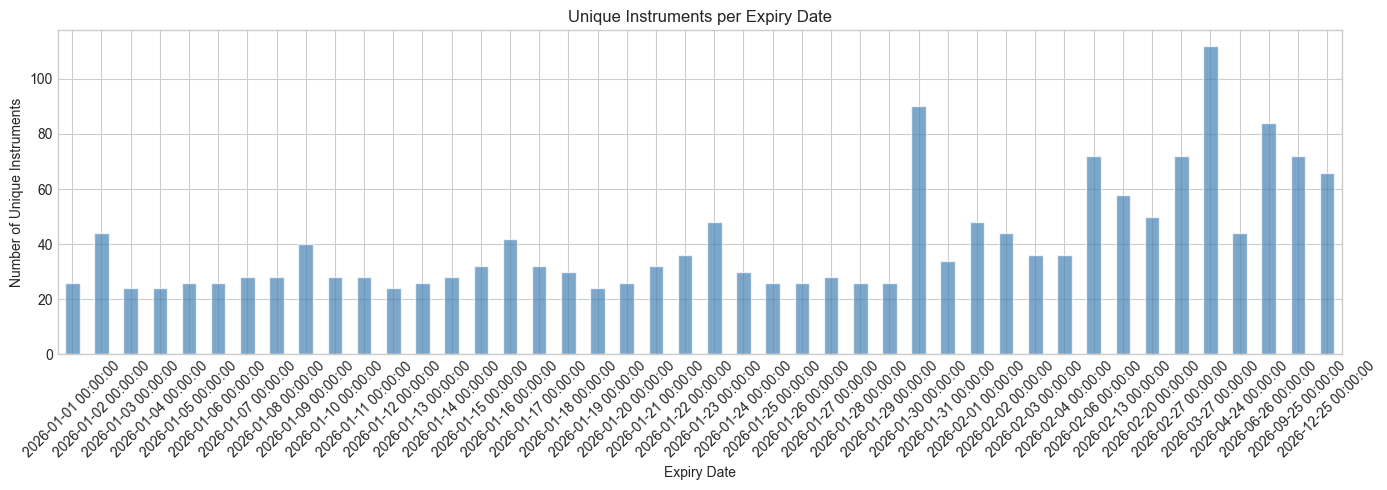


Expiries with most instruments:
expiry_date
2026-03-27    112
2026-01-30     90
2026-06-26     84
2026-09-25     72
2026-02-27     72
2026-02-06     72
2026-12-25     66
2026-02-13     58
2026-02-20     50
2026-02-01     48
Name: market, dtype: int64


In [7]:
# Expiry distribution
expiry_counts = df.groupby("expiry_date")["market"].nunique().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
expiry_counts.plot(kind="bar", ax=ax, color="steelblue", alpha=0.7)
ax.set_xlabel("Expiry Date")
ax.set_ylabel("Number of Unique Instruments")
ax.set_title("Unique Instruments per Expiry Date")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"\nExpiries with most instruments:")
print(expiry_counts.sort_values(ascending=False).head(10))

In [ ]:
# Strike distribution — normalized strike, calls vs puts separately
df["normalized_strike"] = df["strike"] / df["spot_price"]

calls = df[df["option_type"] == "C"]
puts = df[df["option_type"] == "P"]

# Unique instruments per normalized strike bucket
fig, ax = plt.subplots(figsize=(14, 5))

bins = np.arange(0.1, 3.05, 0.05)
call_strikes = calls.drop_duplicates("market")["normalized_strike"]
put_strikes = puts.drop_duplicates("market")["normalized_strike"]

ax.hist(call_strikes, bins=bins, color=CALL_COLOR, alpha=0.6, label="Calls", edgecolor="black", linewidth=0.3)
ax.hist(put_strikes, bins=bins, color=PUT_COLOR, alpha=0.6, label="Puts", edgecolor="black", linewidth=0.3)

# ATM reference
ax.axvline(1.0, color="black", linestyle="--", linewidth=1.5, label="ATM (strike = spot)")
ax.axvspan(0.95, 1.05, alpha=0.1, color="gray", label="ATM band (0.95-1.05)")

ax.set_xlabel("Normalized Strike (Strike / Spot)")
ax.set_ylabel("Number of Unique Instruments")
ax.set_title("Unique Instruments by Normalized Strike — Calls vs Puts")
ax.set_xlim(0.1, 3.0)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nCall instruments: {calls['market'].nunique()}, median normalized strike: {call_strikes.median():.2f}")
print(f"Put instruments:  {puts['market'].nunique()}, median normalized strike: {put_strikes.median():.2f}")
print(f"\nStrike range: ${df['strike'].min():,} — ${df['strike'].max():,}")

In [ ]:
# Normalized strike coverage heatmap — calls vs puts
strike_bins = [0, 0.5, 0.8, 0.95, 1.05, 1.2, 1.5, 3.0]
strike_labels = ["<0.5", "0.5-0.8", "0.8-0.95", "0.95-1.05", "1.05-1.2", "1.2-1.5", ">1.5"]
df["strike_bucket"] = pd.cut(df["normalized_strike"], bins=strike_bins, labels=strike_labels)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, (opt_type, title) in enumerate([("C", "Calls"), ("P", "Puts")]):
    ax = axes[i]
    subset = df[df["option_type"] == opt_type]
    pivot = subset.groupby(["strike_bucket", "expiry_date"]).size().unstack(fill_value=0)
    # Use log scale for color
    import matplotlib.colors as mcolors
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        norm=mcolors.LogNorm(vmin=1, vmax=pivot.values.max() + 1),
        xticklabels=True,
        yticklabels=True,
    )
    ax.set_title(f"Strike vs Expiry Coverage — {title}")
    ax.set_xlabel("Expiry Date")
    ax.set_ylabel("Normalized Strike Bucket")
    # Rotate x labels
    ax.set_xticklabels([t.get_text()[:10] for t in ax.get_xticklabels()], rotation=45, ha="right", fontsize=7)

plt.tight_layout()
plt.show()

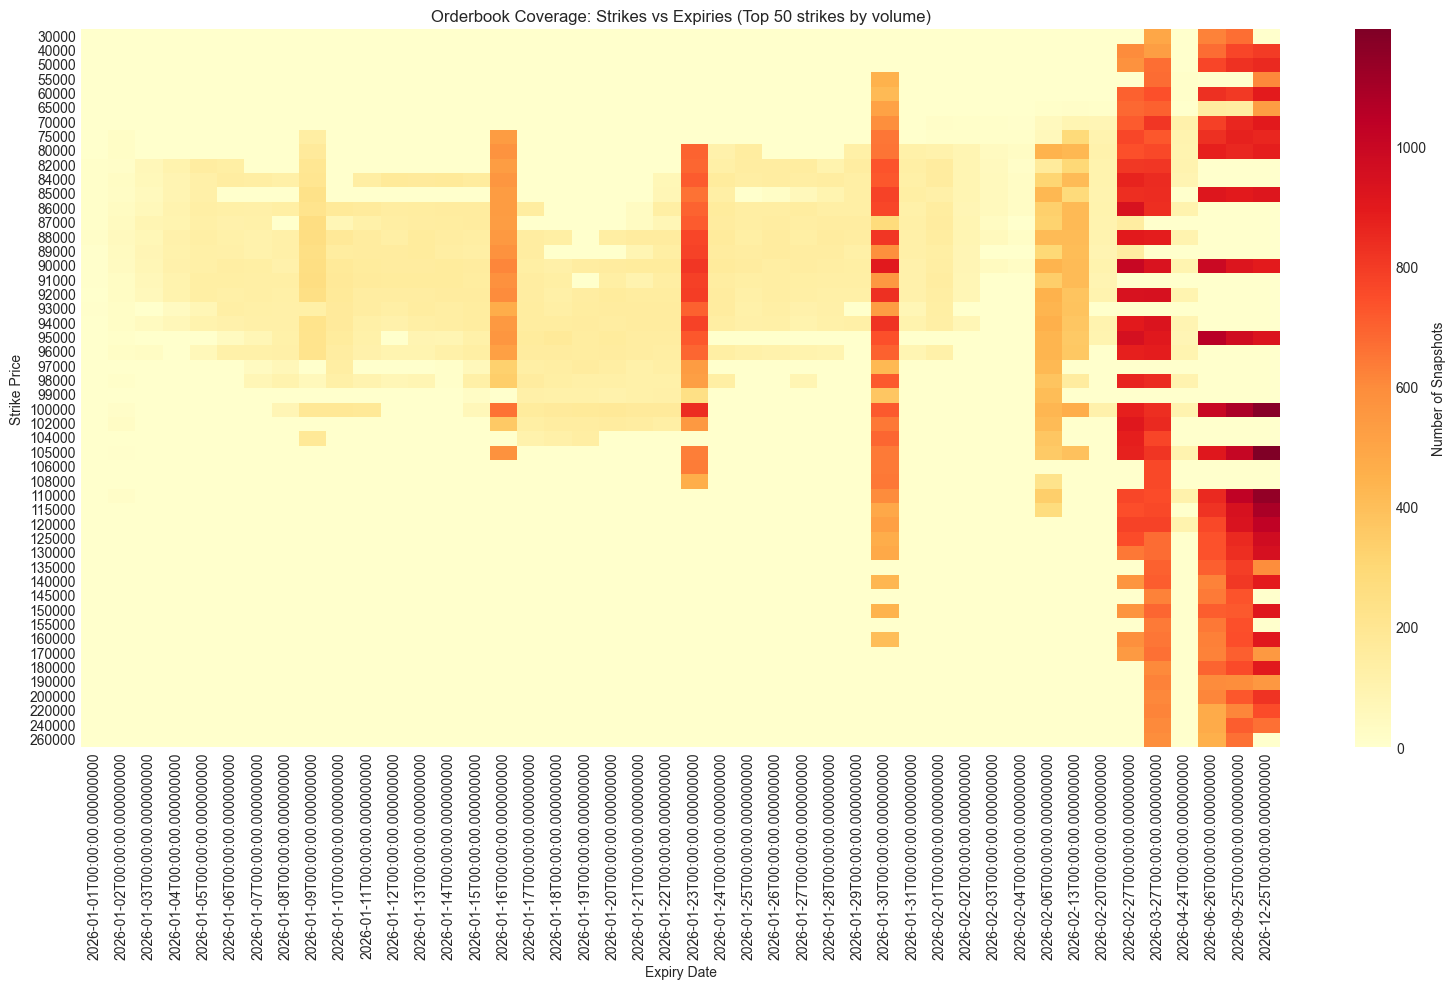

In [9]:
# Heatmap: strikes vs expiries (data availability)
# Create pivot table of record counts
pivot = df.pivot_table(
    values="time", index="strike", columns="expiry_date", aggfunc="count"
).fillna(0)

# Filter to strikes with reasonable coverage (remove extremes)
strike_totals = pivot.sum(axis=1)
top_strikes = strike_totals.nlargest(50).index
pivot_filtered = pivot.loc[pivot.index.isin(top_strikes)].sort_index()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    pivot_filtered, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Number of Snapshots"}
)
ax.set_xlabel("Expiry Date")
ax.set_ylabel("Strike Price")
ax.set_title("Orderbook Coverage: Strikes vs Expiries (Top 50 strikes by volume)")
plt.tight_layout()
plt.show()

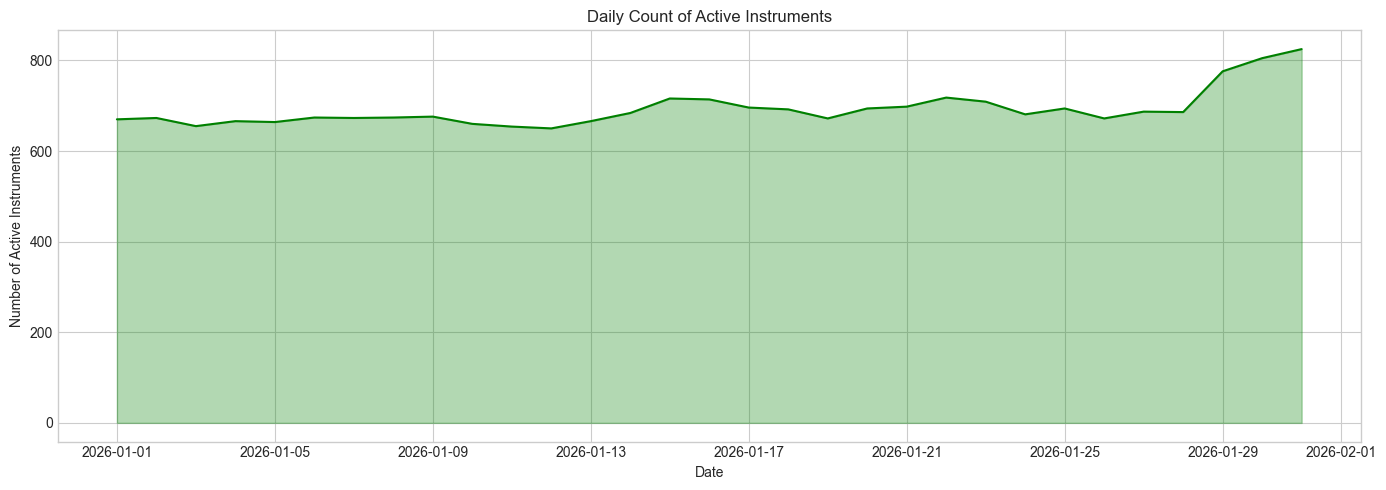

Average daily instruments: 693
Min: 650, Max: 825


In [10]:
# Time series of active instruments
df["date"] = df["time"].dt.date
daily_instruments = df.groupby("date")["market"].nunique()

fig, ax = plt.subplots(figsize=(14, 5))
daily_instruments.plot(ax=ax, color="green", linewidth=1.5)
ax.set_xlabel("Date")
ax.set_ylabel("Number of Active Instruments")
ax.set_title("Daily Count of Active Instruments")
ax.fill_between(
    daily_instruments.index, daily_instruments.values, alpha=0.3, color="green"
)
plt.tight_layout()
plt.show()

print(f"Average daily instruments: {daily_instruments.mean():.0f}")
print(f"Min: {daily_instruments.min()}, Max: {daily_instruments.max()}")

## 3. Liquidity Metrics

In [11]:
# Filter to valid quotes only
valid_quotes = df[
    (df["best_bid"].notna()) & (df["best_ask"].notna()) & (df["spread"] >= 0)
].copy()
print(
    f"Valid two-sided quotes: {len(valid_quotes):,} ({100 * len(valid_quotes) / len(df):.1f}%)"
)

Valid two-sided quotes: 262,414 (95.8%)


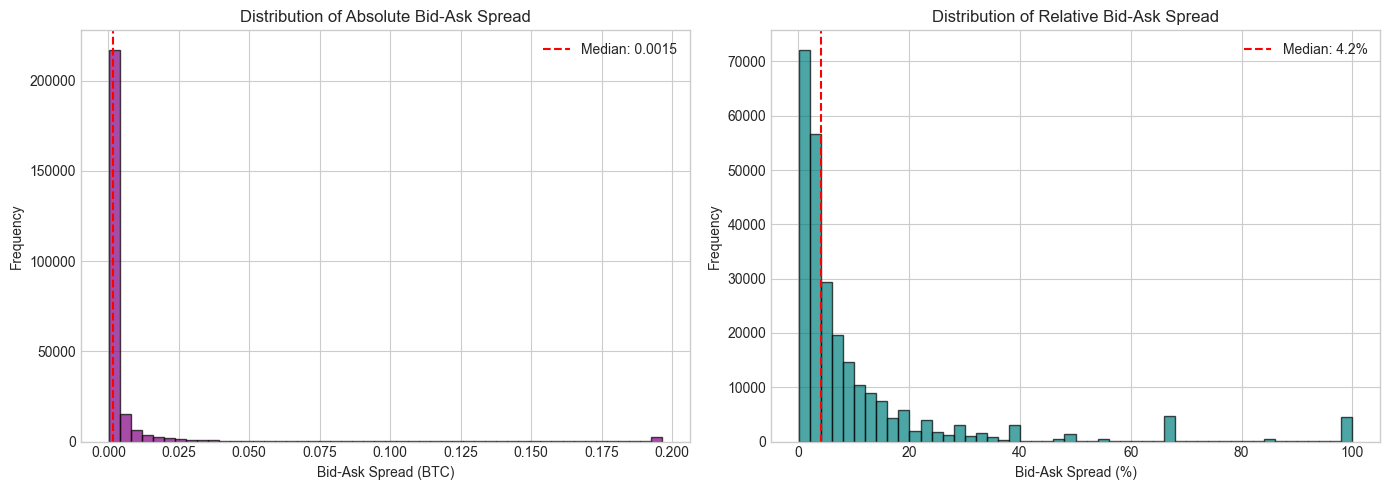


Spread Statistics (BTC):
count    262414.000000
mean          0.009387
std           0.065000
min           0.000100
25%           0.000500
50%           0.001500
75%           0.003000
max          14.999900
Name: spread, dtype: float64

Spread Statistics (%):
count    262414.000000
mean         11.030682
std          19.468277
min           0.065811
25%           1.904762
50%           4.166667
75%          10.958904
max         199.997333
Name: spread_pct, dtype: float64


In [12]:
# Bid-ask spread distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute spread (in BTC terms)
ax = axes[0]
spread_clipped = valid_quotes["spread"].clip(
    upper=valid_quotes["spread"].quantile(0.99)
)
ax.hist(spread_clipped, bins=50, color="purple", alpha=0.7, edgecolor="black")
ax.set_xlabel("Bid-Ask Spread (BTC)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Absolute Bid-Ask Spread")
ax.axvline(
    valid_quotes["spread"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {valid_quotes['spread'].median():.4f}",
)
ax.legend()

# Percentage spread
ax = axes[1]
spread_pct_clipped = valid_quotes["spread_pct"].clip(
    upper=valid_quotes["spread_pct"].quantile(0.99)
)
ax.hist(spread_pct_clipped, bins=50, color="teal", alpha=0.7, edgecolor="black")
ax.set_xlabel("Bid-Ask Spread (%)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Relative Bid-Ask Spread")
ax.axvline(
    valid_quotes["spread_pct"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {valid_quotes['spread_pct'].median():.1f}%",
)
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nSpread Statistics (BTC):")
print(valid_quotes["spread"].describe())
print(f"\nSpread Statistics (%):")
print(valid_quotes["spread_pct"].describe())

In [ ]:
# Calculate moneyness using actual spot prices
def categorize_moneyness(row):
    """Categorize option moneyness based on strike vs spot."""
    spot = row.get("spot_price")
    if pd.isna(spot) or spot == 0:
        return None
    ratio = row["strike"] / spot
    opt_type = row["option_type"]

    if opt_type == "C":  # Call
        if ratio < 0.95:
            return "ITM"
        elif ratio <= 1.05:
            return "ATM"
        else:
            return "OTM"
    else:  # Put
        if ratio > 1.05:
            return "ITM"
        elif ratio >= 0.95:
            return "ATM"
        else:
            return "OTM"


valid_quotes["moneyness"] = valid_quotes.apply(categorize_moneyness, axis=1)
valid_quotes["normalized_strike"] = valid_quotes["strike"] / valid_quotes["spot_price"]

print("=== Moneyness Distribution by Option Type ===")
print(valid_quotes.groupby(["option_type", "moneyness"]).size().unstack(fill_value=0))
print(f"\nOverall: {valid_quotes['moneyness'].value_counts().to_dict()}")

In [ ]:
# Spread by moneyness — calls vs puts
moneyness_order = ["ITM", "ATM", "OTM"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar chart — median spread by moneyness and option type
ax = axes[0]
spread_by_group = valid_quotes.groupby(["moneyness", "option_type"])["spread_pct"].median().unstack()
x = np.arange(len(moneyness_order))
width = 0.35
bars_c = ax.bar(x - width / 2, spread_by_group.reindex(moneyness_order)["C"], width, color=CALL_COLOR, alpha=0.7, edgecolor="black", label="Calls")
bars_p = ax.bar(x + width / 2, spread_by_group.reindex(moneyness_order)["P"], width, color=PUT_COLOR, alpha=0.7, edgecolor="black", label="Puts")
ax.set_xticks(x)
ax.set_xticklabels(moneyness_order)
ax.set_xlabel("Moneyness")
ax.set_ylabel("Median Spread (%)")
ax.set_title("Median Spread by Moneyness — Calls vs Puts")
ax.legend()
for bars in [bars_c, bars_p]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1, f"{h:.1f}%", ha="center", va="bottom", fontsize=9)

# Right: boxplot with 6 groups
ax = axes[1]
plot_data = valid_quotes[valid_quotes["moneyness"].isin(moneyness_order)].copy()
plot_data["group"] = plot_data["moneyness"] + "-" + plot_data["option_type"].map({"C": "Call", "P": "Put"})
group_order = [f"{m}-{t}" for m in moneyness_order for t in ["Call", "Put"]]
plot_data["group"] = pd.Categorical(plot_data["group"], categories=group_order, ordered=True)
box_colors = [CALL_COLOR, PUT_COLOR] * 3
plot_data.boxplot(column="spread_pct", by="group", ax=ax, positions=range(len(group_order)), widths=0.6)
ax.set_ylim(0, valid_quotes["spread_pct"].quantile(0.95))
ax.set_xlabel("Moneyness — Option Type")
ax.set_ylabel("Spread (%)")
ax.set_title("Spread Distribution by Moneyness and Type")
ax.set_xticklabels([g.replace("-", "\n") for g in group_order], fontsize=8)
plt.suptitle("")
plt.tight_layout()
plt.show()

# Summary table
print("\n=== Spread by Moneyness and Option Type ===")
summary = valid_quotes.groupby(["moneyness", "option_type"])["spread_pct"].agg(["count", "median", "mean"]).round(2)
print(summary)

In [ ]:
# Two-sided quote availability by moneyness and option type
# Compute has_both if not yet available
if "has_both" not in df.columns:
    df["has_both"] = df["best_bid"].notna() & df["best_ask"].notna()
if "moneyness" not in df.columns:
    df["moneyness"] = df.apply(categorize_moneyness, axis=1)

moneyness_order = ["ITM", "ATM", "OTM"]
quote_avail = df.groupby(["moneyness", "option_type"])["has_both"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
avail_data = quote_avail.unstack("option_type").reindex(moneyness_order)
x = np.arange(len(moneyness_order))
width = 0.35
bars_c = ax.bar(x - width / 2, avail_data.get("C", 0), width, color=CALL_COLOR, alpha=0.7, edgecolor="black", label="Calls")
bars_p = ax.bar(x + width / 2, avail_data.get("P", 0), width, color=PUT_COLOR, alpha=0.7, edgecolor="black", label="Puts")
ax.set_xticks(x)
ax.set_xticklabels(moneyness_order)
ax.set_xlabel("Moneyness")
ax.set_ylabel("% Snapshots with Two-Sided Quotes")
ax.set_title("Two-Sided Quote Availability — Calls vs Puts by Moneyness")
ax.legend()

for bars in [bars_c, bars_p]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5, f"{h:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

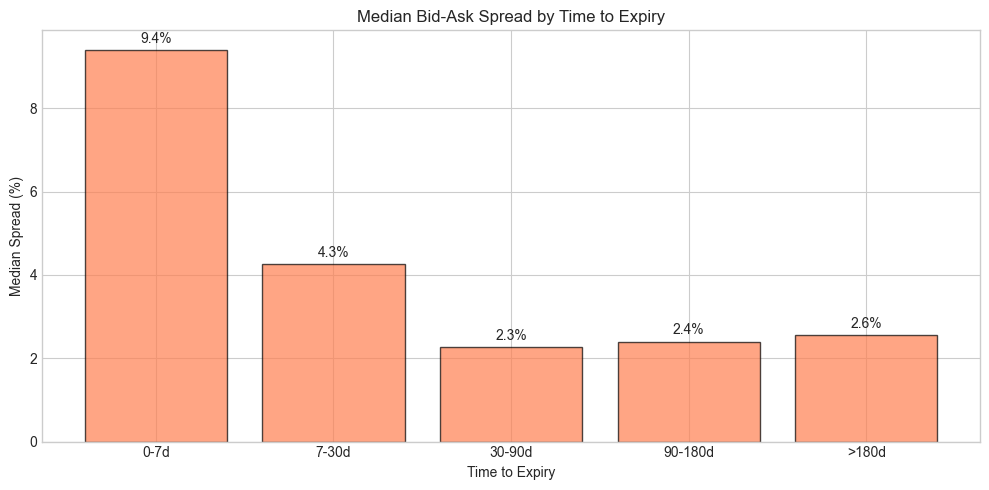


Spread stats by time to expiry:
            count    median       mean        std
tte_bucket                                       
0-7d        66339  9.395973  19.331772  26.347054
7-30d       56619  4.255319   9.340125  14.888428
30-90d      58624  2.272727   8.191545  17.009822
90-180d     27069  2.397602  11.456912  22.783381
>180d       53763  2.554427   5.449438   7.421048


In [15]:
# Calculate time to expiry
# Convert expiry_date to timezone-aware to match time column
valid_quotes["expiry_date_utc"] = pd.to_datetime(
    valid_quotes["expiry_date"]
).dt.tz_localize("UTC")
valid_quotes["tte_days"] = (
    valid_quotes["expiry_date_utc"] - valid_quotes["time"].dt.normalize()
).dt.days


# Bin time to expiry
def tte_bucket(days):
    if pd.isna(days):
        return "Unknown"
    if days <= 7:
        return "0-7d"
    elif days <= 30:
        return "7-30d"
    elif days <= 90:
        return "30-90d"
    elif days <= 180:
        return "90-180d"
    else:
        return ">180d"


valid_quotes["tte_bucket"] = valid_quotes["tte_days"].apply(tte_bucket)

# Spread by time to expiry
fig, ax = plt.subplots(figsize=(10, 5))
tte_order = ["0-7d", "7-30d", "30-90d", "90-180d", ">180d"]
tte_spread = (
    valid_quotes.groupby("tte_bucket")["spread_pct"].median().reindex(tte_order)
)
bars = ax.bar(tte_order, tte_spread.values, color="coral", alpha=0.7, edgecolor="black")
ax.set_xlabel("Time to Expiry")
ax.set_ylabel("Median Spread (%)")
ax.set_title("Median Bid-Ask Spread by Time to Expiry")
for bar, val in zip(bars, tte_spread.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()

print(f"\nSpread stats by time to expiry:")
print(
    valid_quotes.groupby("tte_bucket")["spread_pct"]
    .agg(["count", "median", "mean", "std"])
    .reindex(tte_order)
)

In [ ]:
# Spread by option type — deeper comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

calls_vq = valid_quotes[valid_quotes["option_type"] == "C"]
puts_vq = valid_quotes[valid_quotes["option_type"] == "P"]
clip_upper = valid_quotes["spread_pct"].quantile(0.95)

# Left: overlaid histograms
ax = axes[0]
ax.hist(calls_vq["spread_pct"].clip(upper=clip_upper), bins=50, color=CALL_COLOR, alpha=0.5, label="Calls", edgecolor="black", linewidth=0.3)
ax.hist(puts_vq["spread_pct"].clip(upper=clip_upper), bins=50, color=PUT_COLOR, alpha=0.5, label="Puts", edgecolor="black", linewidth=0.3)
ax.set_xlabel("Spread (%)")
ax.set_ylabel("Frequency")
ax.set_title("Spread Distribution — Calls vs Puts")
ax.legend()

# Middle: median spread by option type AND TTE bucket
ax = axes[1]
spread_by_tte = valid_quotes.groupby(["tte_bucket", "option_type"])["spread_pct"].median().unstack()
tte_order = ["0-7d", "7-30d", "30-90d", "90-180d", ">180d"]
spread_by_tte = spread_by_tte.reindex([b for b in tte_order if b in spread_by_tte.index])
x = np.arange(len(spread_by_tte))
width = 0.35
ax.bar(x - width / 2, spread_by_tte.get("C", 0), width, color=CALL_COLOR, alpha=0.7, edgecolor="black", label="Calls")
ax.bar(x + width / 2, spread_by_tte.get("P", 0), width, color=PUT_COLOR, alpha=0.7, edgecolor="black", label="Puts")
ax.set_xticks(x)
ax.set_xticklabels(spread_by_tte.index, fontsize=9)
ax.set_xlabel("Time to Expiry")
ax.set_ylabel("Median Spread (%)")
ax.set_title("Median Spread by TTE — Calls vs Puts")
ax.legend()

# Right: KDE of spread distributions
ax = axes[2]
calls_vq["spread_pct"].clip(upper=clip_upper).plot.kde(ax=ax, color=CALL_COLOR, label="Calls", linewidth=2)
puts_vq["spread_pct"].clip(upper=clip_upper).plot.kde(ax=ax, color=PUT_COLOR, label="Puts", linewidth=2)
ax.set_xlabel("Spread (%)")
ax.set_ylabel("Density")
ax.set_title("Spread KDE — Calls vs Puts")
ax.set_xlim(0, clip_upper)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Median spread — Calls: {calls_vq['spread_pct'].median():.2f}%, Puts: {puts_vq['spread_pct'].median():.2f}%")
print(f"Mean spread   — Calls: {calls_vq['spread_pct'].mean():.2f}%, Puts: {puts_vq['spread_pct'].mean():.2f}%")

In [17]:
# Orderbook depth analysis
def calculate_depth(orderbook: list, mid_price: float, pct_from_mid: float) -> float:
    """Calculate total size within X% of mid price."""
    if not orderbook or pd.isna(mid_price):
        return 0.0

    threshold = mid_price * pct_from_mid / 100
    total_size = 0.0

    for level in orderbook:
        price = float(level["price"])
        size = float(level["size"])
        if abs(price - mid_price) <= threshold:
            total_size += size

    return total_size


# Calculate depth at various levels (sample for performance)
sample_size = min(50000, len(valid_quotes))
depth_sample = valid_quotes.sample(n=sample_size, random_state=42).copy()

print(f"Calculating depth metrics on {sample_size:,} samples...")

for pct in [1, 5, 10]:
    depth_sample[f"bid_depth_{pct}pct"] = depth_sample.apply(
        lambda x: calculate_depth(x["bids_parsed"], x["mid_price"], pct), axis=1
    )
    depth_sample[f"ask_depth_{pct}pct"] = depth_sample.apply(
        lambda x: calculate_depth(x["asks_parsed"], x["mid_price"], pct), axis=1
    )
    depth_sample[f"total_depth_{pct}pct"] = (
        depth_sample[f"bid_depth_{pct}pct"] + depth_sample[f"ask_depth_{pct}pct"]
    )

print("Done!")

Calculating depth metrics on 50,000 samples...
Done!


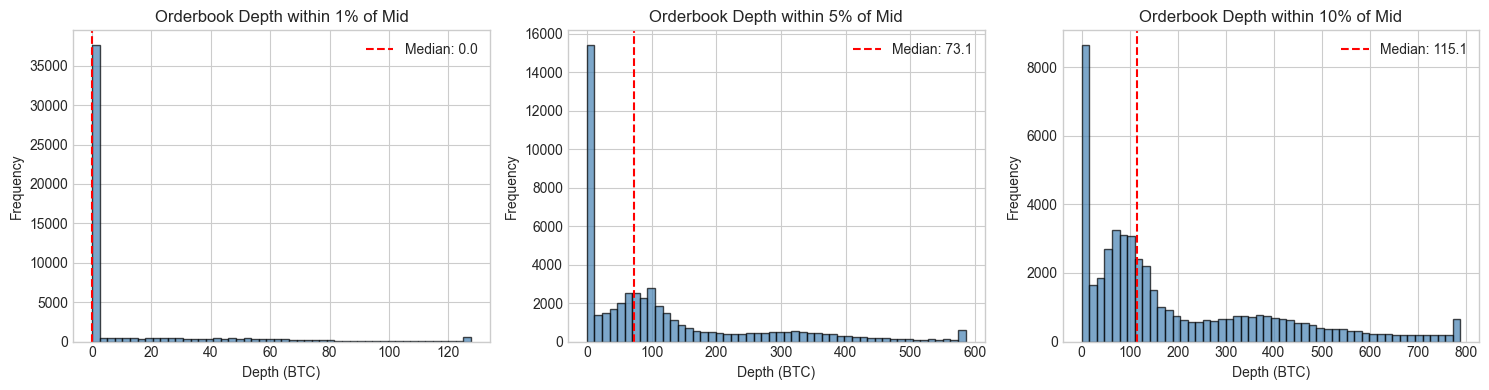

Depth Statistics (BTC):

1% from mid:
  Median: 0.0
  Mean: 11.6
  75th percentile: 2.0

5% from mid:
  Median: 73.1
  Mean: 116.8
  75th percentile: 155.0

10% from mid:
  Median: 115.1
  Mean: 194.8
  75th percentile: 316.4


In [18]:
# Depth distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, pct in enumerate([1, 5, 10]):
    ax = axes[i]
    col = f"total_depth_{pct}pct"
    depth_clipped = depth_sample[col].clip(upper=depth_sample[col].quantile(0.99))
    ax.hist(depth_clipped, bins=50, color="steelblue", alpha=0.7, edgecolor="black")
    ax.set_xlabel("Depth (BTC)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Orderbook Depth within {pct}% of Mid")
    ax.axvline(
        depth_sample[col].median(),
        color="red",
        linestyle="--",
        label=f"Median: {depth_sample[col].median():.1f}",
    )
    ax.legend()

plt.tight_layout()
plt.show()

print("Depth Statistics (BTC):")
for pct in [1, 5, 10]:
    col = f"total_depth_{pct}pct"
    print(f"\n{pct}% from mid:")
    print(f"  Median: {depth_sample[col].median():.1f}")
    print(f"  Mean: {depth_sample[col].mean():.1f}")
    print(f"  75th percentile: {depth_sample[col].quantile(0.75):.1f}")

In [ ]:
# Depth by moneyness and option type
moneyness_order = ["ITM", "ATM", "OTM"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total depth by moneyness and type
ax = axes[0]
depth_by_group = depth_sample.groupby(["moneyness", "option_type"])["total_depth_5pct"].median().unstack()
x = np.arange(len(moneyness_order))
width = 0.35
ax.bar(x - width / 2, depth_by_group.reindex(moneyness_order).get("C", 0), width, color=CALL_COLOR, alpha=0.7, edgecolor="black", label="Calls")
ax.bar(x + width / 2, depth_by_group.reindex(moneyness_order).get("P", 0), width, color=PUT_COLOR, alpha=0.7, edgecolor="black", label="Puts")
ax.set_xticks(x)
ax.set_xticklabels(moneyness_order)
ax.set_ylabel("Median Depth (BTC)")
ax.set_title("Total Depth (5% of mid) by Moneyness")
ax.legend()

# Bid depth
ax = axes[1]
bid_depth = depth_sample.groupby(["moneyness", "option_type"])["bid_depth_5pct"].median().unstack()
ax.bar(x - width / 2, bid_depth.reindex(moneyness_order).get("C", 0), width, color=CALL_COLOR, alpha=0.7, edgecolor="black", label="Calls")
ax.bar(x + width / 2, bid_depth.reindex(moneyness_order).get("P", 0), width, color=PUT_COLOR, alpha=0.7, edgecolor="black", label="Puts")
ax.set_xticks(x)
ax.set_xticklabels(moneyness_order)
ax.set_ylabel("Median Bid Depth (BTC)")
ax.set_title("Bid-Side Depth (5% of mid)")
ax.legend()

# Ask depth
ax = axes[2]
ask_depth = depth_sample.groupby(["moneyness", "option_type"])["ask_depth_5pct"].median().unstack()
ax.bar(x - width / 2, ask_depth.reindex(moneyness_order).get("C", 0), width, color=CALL_COLOR, alpha=0.7, edgecolor="black", label="Calls")
ax.bar(x + width / 2, ask_depth.reindex(moneyness_order).get("P", 0), width, color=PUT_COLOR, alpha=0.7, edgecolor="black", label="Puts")
ax.set_xticks(x)
ax.set_xticklabels(moneyness_order)
ax.set_ylabel("Median Ask Depth (BTC)")
ax.set_title("Ask-Side Depth (5% of mid)")
ax.legend()

plt.tight_layout()
plt.show()

print("\n=== Depth by Moneyness and Option Type (5% of mid) ===")
print(depth_sample.groupby(["moneyness", "option_type"])[["bid_depth_5pct", "ask_depth_5pct", "total_depth_5pct"]].median().round(2))

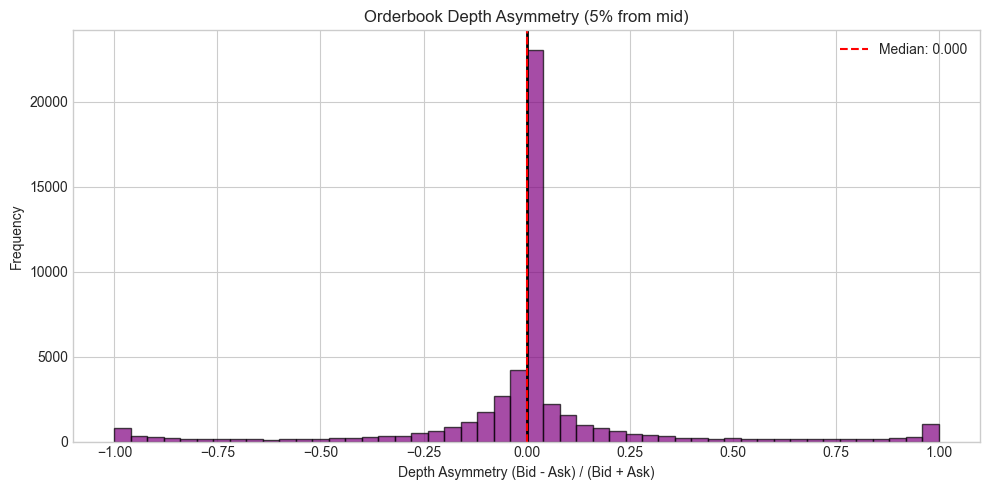

Asymmetry > 0 (more bid depth): 30.4%
Asymmetry < 0 (more ask depth): 32.2%


In [19]:
# Bid/Ask depth asymmetry
depth_sample["depth_asymmetry"] = (
    depth_sample["bid_depth_5pct"] - depth_sample["ask_depth_5pct"]
) / (depth_sample["bid_depth_5pct"] + depth_sample["ask_depth_5pct"] + 1e-10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    depth_sample["depth_asymmetry"].clip(-1, 1),
    bins=50,
    color="purple",
    alpha=0.7,
    edgecolor="black",
)
ax.axvline(0, color="black", linestyle="-", linewidth=2)
ax.axvline(
    depth_sample["depth_asymmetry"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {depth_sample['depth_asymmetry'].median():.3f}",
)
ax.set_xlabel("Depth Asymmetry (Bid - Ask) / (Bid + Ask)")
ax.set_ylabel("Frequency")
ax.set_title("Orderbook Depth Asymmetry (5% from mid)")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Asymmetry > 0 (more bid depth): {(depth_sample['depth_asymmetry'] > 0).sum() / len(depth_sample) * 100:.1f}%"
)
print(
    f"Asymmetry < 0 (more ask depth): {(depth_sample['depth_asymmetry'] < 0).sum() / len(depth_sample) * 100:.1f}%"
)

In [ ]:
# Depth asymmetry by option type
fig, ax = plt.subplots(figsize=(12, 5))

calls_ds = depth_sample[depth_sample["option_type"] == "C"]["depth_asymmetry"].clip(-1, 1)
puts_ds = depth_sample[depth_sample["option_type"] == "P"]["depth_asymmetry"].clip(-1, 1)

ax.hist(calls_ds, bins=50, color=CALL_COLOR, alpha=0.5, label="Calls", edgecolor="black", linewidth=0.3)
ax.hist(puts_ds, bins=50, color=PUT_COLOR, alpha=0.5, label="Puts", edgecolor="black", linewidth=0.3)
ax.axvline(0, color="black", linestyle="-", linewidth=1.5)
ax.axvline(calls_ds.median(), color=CALL_COLOR, linestyle="--", linewidth=2, label=f"Call median: {calls_ds.median():.3f}")
ax.axvline(puts_ds.median(), color=PUT_COLOR, linestyle="--", linewidth=2, label=f"Put median: {puts_ds.median():.3f}")
ax.set_xlabel("Depth Asymmetry (Bid - Ask) / (Bid + Ask)")
ax.set_ylabel("Frequency")
ax.set_title("Orderbook Depth Asymmetry — Calls vs Puts")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Positive asymmetry (more bid depth) — Calls: {(calls_ds > 0).mean()*100:.1f}%, Puts: {(puts_ds > 0).mean()*100:.1f}%")

In [20]:
# Quote quality: % of snapshots with valid two-sided quotes
df["has_bid"] = df["best_bid"].notna()
df["has_ask"] = df["best_ask"].notna()
df["has_both"] = df["has_bid"] & df["has_ask"]

quote_quality = pd.DataFrame(
    {
        "Has Bid": [df["has_bid"].mean() * 100],
        "Has Ask": [df["has_ask"].mean() * 100],
        "Has Both": [df["has_both"].mean() * 100],
    }
).T
quote_quality.columns = ["Percentage"]

print("Quote Quality Summary:")
print(quote_quality.round(1))

# Quote quality by moneyness (using full dataset)
df["moneyness"] = df.apply(
    lambda x: categorize_moneyness(x) if pd.notna(x["strike"]) else None, axis=1
)
quality_by_moneyness = df.groupby("moneyness")["has_both"].mean() * 100
print(f"\nTwo-sided quote availability by moneyness:")
print(quality_by_moneyness.round(1))

Quote Quality Summary:
          Percentage
Has Bid         96.1
Has Ask         98.8
Has Both        95.8

Two-sided quote availability by moneyness:
moneyness
ATM    97.1
ITM    96.8
OTM    94.2
Name: has_both, dtype: float64


## 4. Market Microstructure

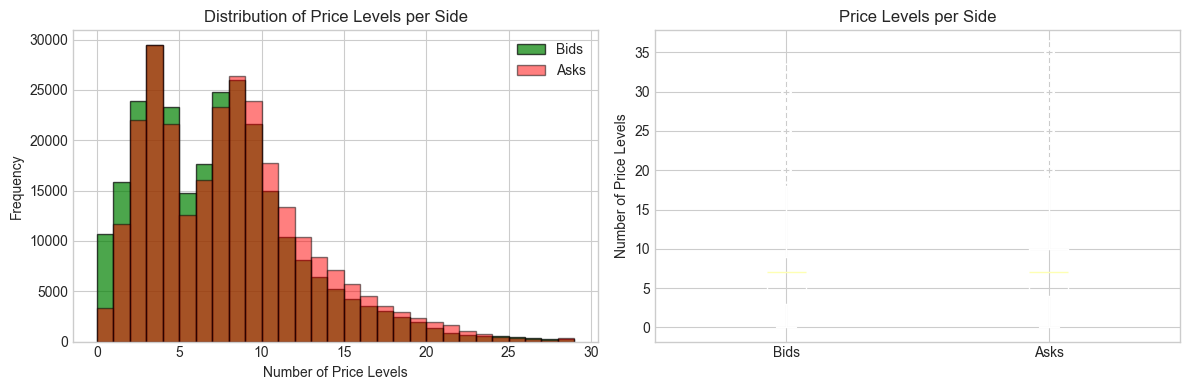

Average bid levels: 6.9
Average ask levels: 7.7


In [21]:
# Number of price levels per side
df["n_bid_levels"] = df["bids_parsed"].apply(len)
df["n_ask_levels"] = df["asks_parsed"].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(
    df["n_bid_levels"],
    bins=range(0, 30),
    color="green",
    alpha=0.7,
    label="Bids",
    edgecolor="black",
)
ax.hist(
    df["n_ask_levels"],
    bins=range(0, 30),
    color="red",
    alpha=0.5,
    label="Asks",
    edgecolor="black",
)
ax.set_xlabel("Number of Price Levels")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Price Levels per Side")
ax.legend()

ax = axes[1]
ax.boxplot([df["n_bid_levels"], df["n_ask_levels"]], labels=["Bids", "Asks"])
ax.set_ylabel("Number of Price Levels")
ax.set_title("Price Levels per Side")

plt.tight_layout()
plt.show()

print(f"Average bid levels: {df['n_bid_levels'].mean():.1f}")
print(f"Average ask levels: {df['n_ask_levels'].mean():.1f}")

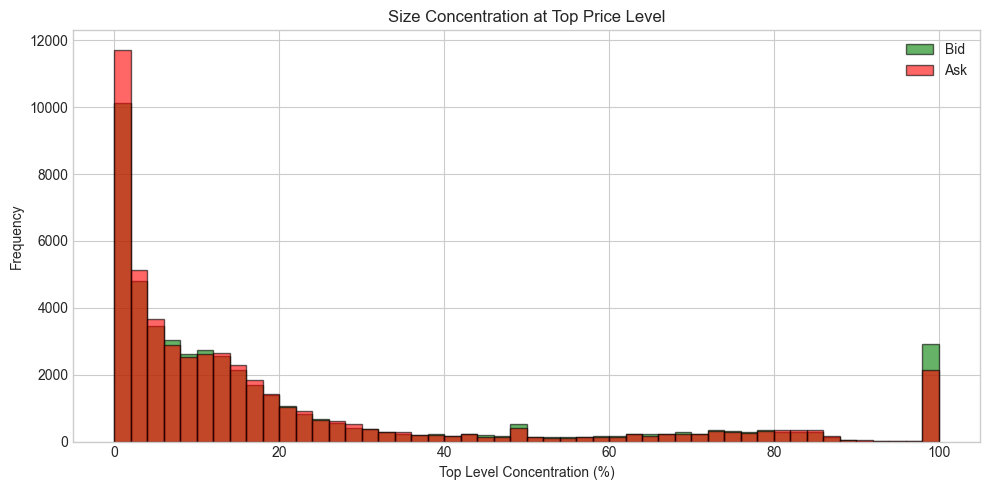

Median bid concentration: 10.0%
Median ask concentration: 9.0%


In [22]:
# Size concentration (% of total depth at top level)
def top_level_concentration(orderbook: list) -> float:
    """Calculate % of total size at top price level."""
    if not orderbook or len(orderbook) == 0:
        return np.nan

    total = sum(float(level["size"]) for level in orderbook)
    if total == 0:
        return np.nan

    top_size = float(orderbook[0]["size"])
    return (top_size / total) * 100


# Sample for performance
conc_sample = df.sample(n=min(50000, len(df)), random_state=42).copy()
conc_sample["bid_concentration"] = conc_sample["bids_parsed"].apply(
    top_level_concentration
)
conc_sample["ask_concentration"] = conc_sample["asks_parsed"].apply(
    top_level_concentration
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    conc_sample["bid_concentration"].dropna(),
    bins=50,
    color="green",
    alpha=0.6,
    label="Bid",
    edgecolor="black",
)
ax.hist(
    conc_sample["ask_concentration"].dropna(),
    bins=50,
    color="red",
    alpha=0.6,
    label="Ask",
    edgecolor="black",
)
ax.set_xlabel("Top Level Concentration (%)")
ax.set_ylabel("Frequency")
ax.set_title("Size Concentration at Top Price Level")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median bid concentration: {conc_sample['bid_concentration'].median():.1f}%")
print(f"Median ask concentration: {conc_sample['ask_concentration'].median():.1f}%")

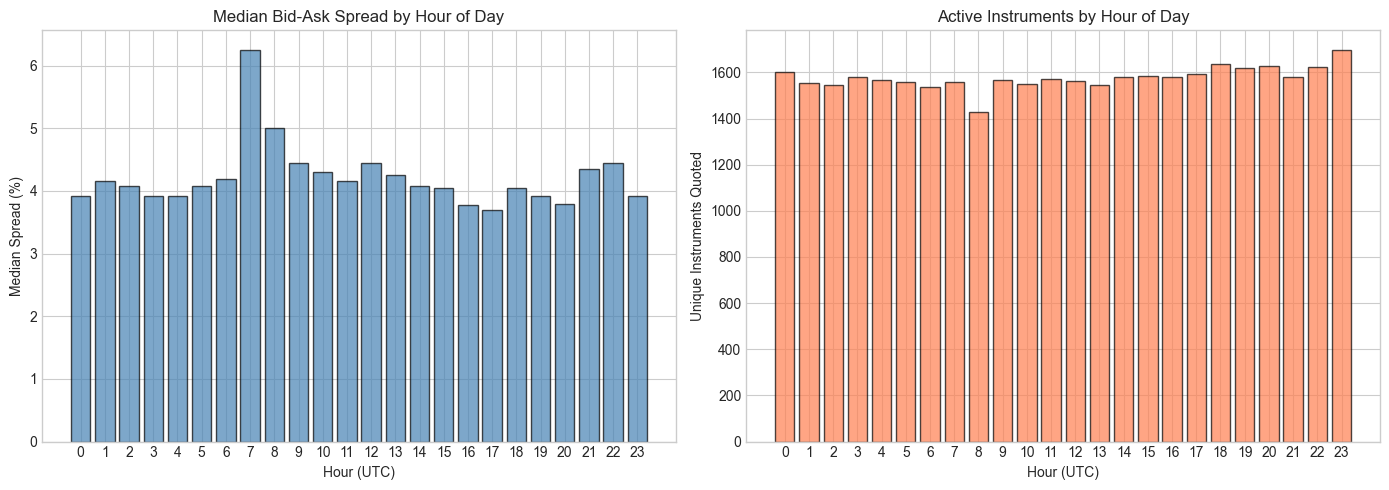

In [23]:
# Time-of-day patterns in liquidity
df["hour"] = df["time"].dt.hour

# Filter to valid quotes
hourly_valid = df[df["has_both"]].copy()

# Spread by hour
hourly_spread = hourly_valid.groupby("hour")["spread_pct"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(
    hourly_spread.index,
    hourly_spread.values,
    color="steelblue",
    alpha=0.7,
    edgecolor="black",
)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Median Spread (%)")
ax.set_title("Median Bid-Ask Spread by Hour of Day")
ax.set_xticks(range(0, 24))

# Active instruments by hour
hourly_instruments = df.groupby("hour")["market"].nunique()
ax = axes[1]
ax.bar(
    hourly_instruments.index,
    hourly_instruments.values,
    color="coral",
    alpha=0.7,
    edgecolor="black",
)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Unique Instruments Quoted")
ax.set_title("Active Instruments by Hour of Day")
ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [ ]:
# Intraday spread by option type
hourly_spread_by_type = df[df["has_both"]].groupby(["hour", "option_type"])["spread_pct"].median().unstack()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hourly_spread_by_type.index, hourly_spread_by_type.get("C", []), color=CALL_COLOR, marker="o", markersize=4, linewidth=2, label="Calls")
ax.plot(hourly_spread_by_type.index, hourly_spread_by_type.get("P", []), color=PUT_COLOR, marker="s", markersize=4, linewidth=2, label="Puts")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Median Spread (%)")
ax.set_title("Intraday Spread Pattern — Calls vs Puts")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Data Quality Checks

In [24]:
# Missing/empty orderbooks
empty_bids = (df["n_bid_levels"] == 0).sum()
empty_asks = (df["n_ask_levels"] == 0).sum()
empty_both = ((df["n_bid_levels"] == 0) & (df["n_ask_levels"] == 0)).sum()

print("=== Empty Orderbook Analysis ===")
print(f"Empty bid side: {empty_bids:,} ({100 * empty_bids / len(df):.2f}%)")
print(f"Empty ask side: {empty_asks:,} ({100 * empty_asks / len(df):.2f}%)")
print(f"Both sides empty: {empty_both:,} ({100 * empty_both / len(df):.2f}%)")

=== Empty Orderbook Analysis ===
Empty bid side: 10,690 (3.90%)
Empty ask side: 3,367 (1.23%)
Both sides empty: 2,682 (0.98%)


In [25]:
# Zero-size levels check
def has_zero_size(orderbook: list) -> bool:
    """Check if any level has zero size."""
    for level in orderbook:
        if float(level["size"]) == 0:
            return True
    return False


# Sample check
zero_check_sample = df.sample(n=min(50000, len(df)), random_state=42)
zero_bid = zero_check_sample["bids_parsed"].apply(has_zero_size).sum()
zero_ask = zero_check_sample["asks_parsed"].apply(has_zero_size).sum()

print("=== Zero-Size Level Check (sampled) ===")
print(
    f"Orderbooks with zero-size bids: {zero_bid:,} ({100 * zero_bid / len(zero_check_sample):.2f}%)"
)
print(
    f"Orderbooks with zero-size asks: {zero_ask:,} ({100 * zero_ask / len(zero_check_sample):.2f}%)"
)

=== Zero-Size Level Check (sampled) ===
Orderbooks with zero-size bids: 0 (0.00%)
Orderbooks with zero-size asks: 0 (0.00%)


In [26]:
# Price inversions (crossed books)
crossed_books = df[
    (df["best_bid"].notna())
    & (df["best_ask"].notna())
    & (df["best_bid"] > df["best_ask"])
]
print("=== Crossed Book Analysis ===")
print(
    f"Crossed orderbooks: {len(crossed_books):,} ({100 * len(crossed_books) / len(df):.4f}%)"
)

if len(crossed_books) > 0:
    print(f"\nExample crossed books:")
    print(crossed_books[["market", "time", "best_bid", "best_ask"]].head())

=== Crossed Book Analysis ===
Crossed orderbooks: 0 (0.0000%)


In [27]:
# Time series gaps
# Check hourly continuity per instrument
def check_gaps(group):
    """Check for gaps > 1 hour in time series."""
    times = group["time"].sort_values()
    if len(times) < 2:
        return 0
    diffs = times.diff().dt.total_seconds() / 3600  # Convert to hours
    gaps = (diffs > 1.5).sum()  # Count gaps > 1.5 hours
    return gaps


# Sample of instruments to check
top_instruments = df["market"].value_counts().head(20).index
gap_counts = df[df["market"].isin(top_instruments)].groupby("market").apply(check_gaps)

print("=== Time Series Gaps (top 20 instruments by volume) ===")
print(f"Total gaps > 1.5 hours: {gap_counts.sum()}")
print(f"Instruments with gaps: {(gap_counts > 0).sum()}")
if gap_counts.sum() > 0:
    print(f"\nInstruments with most gaps:")
    print(gap_counts[gap_counts > 0].sort_values(ascending=False).head())

=== Time Series Gaps (top 20 instruments by volume) ===
Total gaps > 1.5 hours: 2529
Instruments with gaps: 20

Instruments with most gaps:
market
deribit-BTC-27FEB26-105000-C-option    151
deribit-BTC-26JUN26-95000-P-option     149
deribit-BTC-27FEB26-102000-C-option    141
deribit-BTC-25SEP26-105000-C-option    141
deribit-BTC-25DEC26-85000-P-option     136
dtype: int64


In [28]:
# Data quality summary
print("\n" + "=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

total_records = len(df)
valid_twosided = (df["has_both"]).sum()
uncrossed = ((df["has_both"]) & (df["best_bid"] <= df["best_ask"])).sum()

print(f"\nTotal records: {total_records:,}")
print(
    f"Two-sided quotes: {valid_twosided:,} ({100 * valid_twosided / total_records:.1f}%)"
)
print(f"Valid (uncrossed): {uncrossed:,} ({100 * uncrossed / total_records:.1f}%)")


DATA QUALITY SUMMARY

Total records: 273,789
Two-sided quotes: 262,414 (95.8%)
Valid (uncrossed): 262,414 (95.8%)


## 6. Yield Curve Relevance Summary

In [29]:
# Liquidity by expiry
expiry_liquidity = (
    valid_quotes.groupby("expiry_date")
    .agg({"spread_pct": "median", "market": "nunique", "time": "count"})
    .rename(
        columns={
            "spread_pct": "median_spread_pct",
            "market": "n_instruments",
            "time": "n_snapshots",
        }
    )
)

expiry_liquidity = expiry_liquidity.sort_index()
print("=== Liquidity by Expiry ===")
print(expiry_liquidity.head(15))

=== Liquidity by Expiry ===
             median_spread_pct  n_instruments  n_snapshots
expiry_date                                               
2026-01-01           22.222222             18           75
2026-01-02           11.764706             36          463
2026-01-03           18.181818             24          694
2026-01-04           22.222222             24         1003
2026-01-05           15.384615             26         1462
2026-01-06           10.526316             26         1472
2026-01-07           12.500000             28         1464
2026-01-08           12.500000             28         1502
2026-01-09            8.333333             40         3958
2026-01-10           11.764706             28         2018
2026-01-11           16.216216             28         1711
2026-01-12           18.181818             24         1506
2026-01-13           17.142857             26         1653
2026-01-14           12.682927             28         1624
2026-01-15           11.1111

In [30]:
# Recommend liquid expiries (spread < 10% and sufficient snapshots)
liquid_expiries = expiry_liquidity[
    (expiry_liquidity["median_spread_pct"] < 10)
    & (expiry_liquidity["n_snapshots"] > 1000)
]

print("\n=== Recommended Expiries for Yield Curve Construction ===")
print(f"Expiries with median spread < 10% and >1000 snapshots:")
print(liquid_expiries)


=== Recommended Expiries for Yield Curve Construction ===
Expiries with median spread < 10% and >1000 snapshots:
             median_spread_pct  n_instruments  n_snapshots
expiry_date                                               
2026-01-09            8.333333             40         3958
2026-01-16            6.211180             42        10588
2026-01-17            8.092486             32         2077
2026-01-18            9.302326             30         1814
2026-01-21            9.090909             32         1804
2026-01-22            7.792208             36         2094
2026-01-23            5.347594             48        15098
2026-01-24            8.000000             30         2028
2026-01-25            9.523810             26         1601
2026-01-27            8.695652             28         1614
2026-01-28            8.484848             26         1555
2026-01-29            8.333333             26         1668
2026-01-30            4.255319             90        24125
2

In [ ]:
# Liquidity by moneyness and option type
moneyness_liquidity = valid_quotes.groupby(["moneyness", "option_type"]).agg(
    {"spread_pct": ["median", "mean"], "market": "nunique", "time": "count"}
)
moneyness_liquidity.columns = [
    "median_spread",
    "mean_spread",
    "n_instruments",
    "n_snapshots",
]

print("\n=== Liquidity by Moneyness and Option Type ===")
print(moneyness_liquidity.round(2))

# Summary visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
moneyness_order = ["ITM", "ATM", "OTM"]

for i, (col, title) in enumerate([
    ("median_spread", "Median Spread (%)"),
    ("n_instruments", "Unique Instruments"),
    ("n_snapshots", "Total Snapshots"),
]):
    ax = axes[i]
    data = moneyness_liquidity[col].unstack("option_type").reindex(moneyness_order)
    x = np.arange(len(moneyness_order))
    width = 0.35
    ax.bar(x - width / 2, data.get("C", 0), width, color=CALL_COLOR, alpha=0.7, edgecolor="black", label="Calls")
    ax.bar(x + width / 2, data.get("P", 0), width, color=PUT_COLOR, alpha=0.7, edgecolor="black", label="Puts")
    ax.set_xticks(x)
    ax.set_xticklabels(moneyness_order)
    ax.set_ylabel(title)
    ax.set_title(title + " by Moneyness")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Call/Put Bias Summary
print("=" * 60)
print("CALL vs PUT MARKET STRUCTURE SUMMARY")
print("=" * 60)

n_call_instruments = df[df["option_type"] == "C"]["market"].nunique()
n_put_instruments = df[df["option_type"] == "P"]["market"].nunique()
call_median_strike = df[df["option_type"] == "C"].drop_duplicates("market")["normalized_strike"].median()
put_median_strike = df[df["option_type"] == "P"].drop_duplicates("market")["normalized_strike"].median()

call_spread = valid_quotes[valid_quotes["option_type"] == "C"]["spread_pct"].median()
put_spread = valid_quotes[valid_quotes["option_type"] == "P"]["spread_pct"].median()

print(f"\n1. INSTRUMENT COUNT: {n_call_instruments} calls vs {n_put_instruments} puts (ratio: {n_call_instruments/n_put_instruments:.2f}x)")
print(f"2. STRIKE SKEW: Call median normalized strike: {call_median_strike:.2f}, Put median: {put_median_strike:.2f}")
print(f"3. SPREAD: Call median: {call_spread:.2f}%, Put median: {put_spread:.2f}%")

if n_call_instruments > n_put_instruments * 1.1:
    bias = "CALL-HEAVY — consistent with speculation-driven (long upside) crypto market dynamics"
elif n_put_instruments > n_call_instruments * 1.1:
    bias = "PUT-HEAVY — consistent with hedging-driven dynamics"
else:
    bias = "BALANCED"
print(f"\n4. OVERALL: {bias}")
print(f"\nKey insight: In crypto options markets, the call/put skew reflects")
print(f"speculative positioning (bullish = more OTM calls) rather than")
print(f"traditional hedging demand (bearish = more OTM puts).")

In [32]:
# Final recommendations
print("\n" + "=" * 60)
print("RECOMMENDATIONS FOR YIELD CURVE CONSTRUCTION")
print("=" * 60)

print("""
1. EXPIRY SELECTION:
   - Focus on major expiries (monthly/quarterly) which have better liquidity
   - Weekly expiries have wider spreads and less depth
   - Expiries with >1000 snapshots and <10% median spread are most reliable

2. STRIKE SELECTION:
   - ATM options (within 5% of spot) have tightest spreads
   - OTM options have wider spreads but more volume
   - ITM options are less liquid, use with caution

3. DATA FILTERING CRITERIA:
   - Require two-sided quotes (both bid and ask present)
   - Filter out crossed books (bid > ask)
   - Consider spread threshold: <10% for reliable pricing
   - Prefer snapshots with depth > 10 BTC within 5% of mid

4. TEMPORAL CONSIDERATIONS:
   - Liquidity is relatively stable across hours (24/7 market)
   - May see slightly wider spreads during Asian hours
   
5. QUOTE QUALITY:
   - Most snapshots have valid two-sided quotes
   - ATM options have highest quote availability
""")

print("\n=== KEY METRICS ===")
print(f"Dataset date range: {df['time'].min().date()} to {df['time'].max().date()}")
print(f"Total records: {len(df):,}")
print(f"Unique instruments: {df['market'].nunique():,}")
print(f"Unique expiries: {df['expiry_date'].nunique()}")
print(f"Overall median spread: {valid_quotes['spread_pct'].median():.1f}%")
print(
    f"ATM median spread: {valid_quotes[valid_quotes['moneyness'] == 'ATM']['spread_pct'].median():.1f}%"
)


RECOMMENDATIONS FOR YIELD CURVE CONSTRUCTION

1. EXPIRY SELECTION:
   - Focus on major expiries (monthly/quarterly) which have better liquidity
   - Weekly expiries have wider spreads and less depth
   - Expiries with >1000 snapshots and <10% median spread are most reliable

2. STRIKE SELECTION:
   - ATM options (within 5% of spot) have tightest spreads
   - OTM options have wider spreads but more volume
   - ITM options are less liquid, use with caution

3. DATA FILTERING CRITERIA:
   - Require two-sided quotes (both bid and ask present)
   - Filter out crossed books (bid > ask)
   - Consider spread threshold: <10% for reliable pricing
   - Prefer snapshots with depth > 10 BTC within 5% of mid

4. TEMPORAL CONSIDERATIONS:
   - Liquidity is relatively stable across hours (24/7 market)
   - May see slightly wider spreads during Asian hours

5. QUOTE QUALITY:
   - Most snapshots have valid two-sided quotes
   - ATM options have highest quote availability


=== KEY METRICS ===
Dataset da